In [7]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification

In [8]:
# 1) Generate a sample binary classification dataset
X, y = make_classification(
    n_samples=5000, n_features=20, n_informative=10, n_redundant=5,
    n_classes=2, class_sep=1.0, random_state=42
)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
fit_times = []
accuracies = []
sample_sizes = np.linspace(200, len(X_train), 12, dtype=int)

In [11]:
for size in sample_sizes:
    X_sub, y_sub = X_train[:size], y_train[:size]

    model = LogisticRegression(max_iter=1000, n_jobs=1)

    start = time.time()
    model.fit(X_sub, y_sub)
    end = time.time()

    fit_times.append(end - start)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

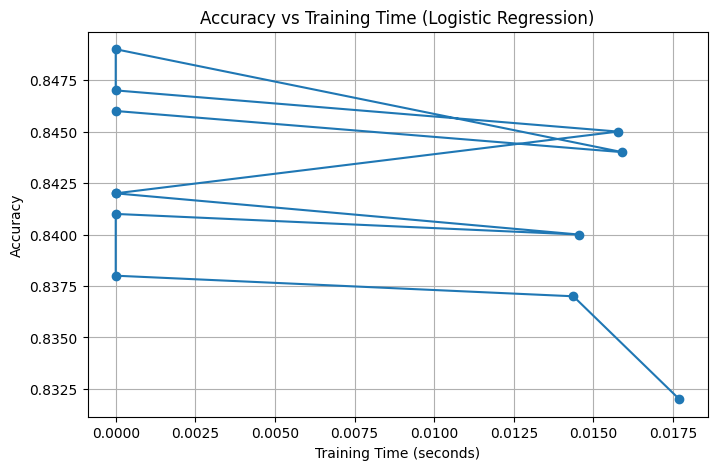

In [12]:
plt.figure(figsize=(8,5))
plt.plot(fit_times, accuracies, marker='o')
plt.title('Accuracy vs Training Time (Logistic Regression)')
plt.xlabel('Training Time (seconds)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

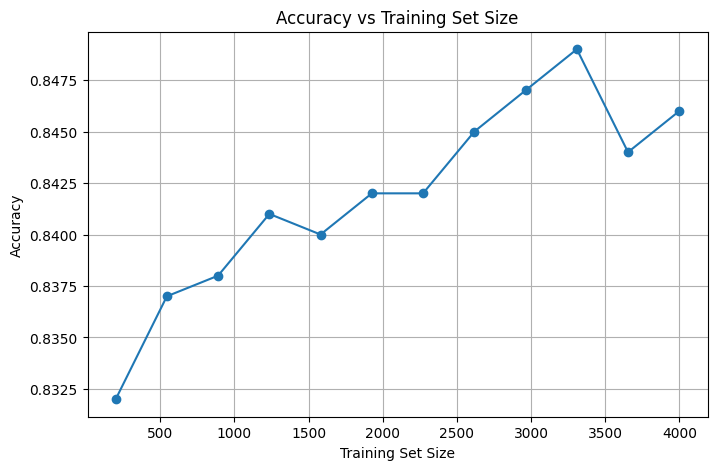

In [13]:
plt.figure(figsize=(8,5))
plt.plot(sample_sizes, accuracies, marker='o')
plt.title('Accuracy vs Training Set Size')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

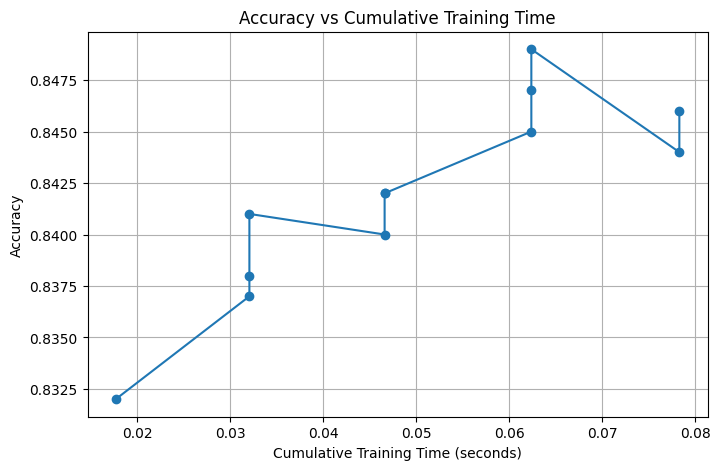

In [14]:
import numpy as np

cum_times = np.cumsum(fit_times)  # turn per-run times into a growing total
plt.figure(figsize=(8,5))
plt.plot(cum_times, accuracies, marker='o')
plt.title('Accuracy vs Cumulative Training Time')
plt.xlabel('Cumulative Training Time (seconds)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()